<a href="https://colab.research.google.com/github/madeseor/estructuras-de-bases-de-datos/blob/main/Quadtree/Quadtree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arbol-Quadtree

## Introducción

Este notebook implementa un *Quadtree 2D* desde cero y lo compara con una búsqueda de *fuerza bruta* para resolver dos problemas clave en logística:

1.  **Búsqueda por radio (Range Search)**: Encontrar todos los puntos de entrega dentro de una distancia específica de un punto dado.
2.  **Vecino más cercano (Nearest Neighbor)**: Identificar el punto de entrega más cercano a un punto de consulta.

El objetivo es analizar el rendimiento de ambas aproximaciones con diferentes volúmenes de datos, simulando un escenario de planificación de rutas en una ciudad.

## 1. Configuraciones


Esta sección contiene las importaciones de bibliotecas necesarias y la definición de la estructura de datos `Point`.

In [25]:
import math
import time
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from collections import namedtuple

# Estructura para representar un punto en 2D con un ID único.
Point = namedtuple("Point", ["x", "y", "id"])

## 2. Estructuras Base del Quadtree

Aquí se define la clase `BoundingBox`, que representa un rectángulo delimitador. Es fundamental para el Quadtree, ya que permite definir las áreas cubiertas por cada nodo y realizar comprobaciones eficientes de intersección con otros objetos (puntos o círculos).

In [26]:
class BoundingBox:
    """
    Rectángulo delimitador (AABB) para cada nodo del Quadtree.
    cx, cy = centro;  hw, hh = half-width, half-height
    """
    def __init__(self, cx, cy, hw, hh):
        self.cx = cx
        self.cy = cy
        self.hw = hw
        self.hh = hh

    def contains(self, point):
        """¿El punto está dentro (o en el borde) del bounding box?"""
        return (self.cx - self.hw <= point.x <= self.cx + self.hw and
                self.cy - self.hh <= point.y <= self.cy + self.hh)

    def intersects_circle(self, cx, cy, r):
        """
        ¿El bounding box intersecta con el círculo (cx, cy, r)?
        Usamos la distancia del centro del círculo al punto más cercano del AABB.
        """
        # Punto más cercano del AABB al centro del círculo
        nearest_x = max(self.cx - self.hw, min(cx, self.cx + self.hw))
        nearest_y = max(self.cy - self.hh, min(cy, self.cy + self.hh))
        dist_sq = (cx - nearest_x) ** 2 + (cy - nearest_y) ** 2
        return dist_sq <= r * r

    def intersects_box(self, other):
        """¿Dos bounding boxes se solapan?"""
        return (abs(self.cx - other.cx) <= self.hw + other.hw and
                abs(self.cy - other.cy) <= self.hh + other.hh)

## 3. Implementación del QuadtreeNode

La clase `QuadtreeNode` es el corazón de la estructura del Quadtree. Cada nodo gestiona un área geográfica (`BoundingBox`) y almacena puntos hasta que alcanza su capacidad máxima (`MAX_CAPACITY`), momento en el cual se subdivide en cuatro cuadrantes hijos (Noreste, Noroeste, Sureste, Suroeste). Incluye métodos para inserción de puntos, búsqueda por radio (`range_search`), y búsqueda del vecino más cercano (`nearest_neighbor`) con optimizaciones de poda.

In [27]:
class QuadtreeNode:
    """
    Nodo del Quadtree.
    Cada nodo tiene capacidad MAX_CAPACITY antes de subdividirse.
    """
    MAX_CAPACITY = 8   # puntos por nodo hoja (ajustable)
    MAX_DEPTH    = 20  # profundidad máxima para evitar recursión infinita

    def __init__(self, boundary: BoundingBox, depth: int = 0):
        self.boundary  = boundary
        self.depth     = depth
        self.points    = []        # puntos en este nodo (solo si es hoja)
        self.divided   = False     # ¿ya se subdividió?
        self.ne = self.nw = self.se = self.sw = None  # hijos

    def subdivide(self):
        cx, cy = self.boundary.cx, self.boundary.cy
        hw, hh = self.boundary.hw / 2, self.boundary.hh / 2

        self.ne = QuadtreeNode(BoundingBox(cx + hw, cy + hh, hw, hh), self.depth + 1)
        self.nw = QuadtreeNode(BoundingBox(cx - hw, cy + hh, hw, hh), self.depth + 1)
        self.se = QuadtreeNode(BoundingBox(cx + hw, cy - hh, hw, hh), self.depth + 1)
        self.sw = QuadtreeNode(BoundingBox(cx - hw, cy - hh, hw, hh), self.depth + 1)
        self.divided = True

        # Redistribuir los puntos existentes en los hijos
        for p in self.points:
            self._insert_in_children(p)
        self.points = []  # el nodo interno ya no guarda puntos

    def _insert_in_children(self, point):
        for child in (self.ne, self.nw, self.se, self.sw):
            if child.boundary.contains(point):
                child.insert(point)
                return

    def insert(self, point: Point) -> bool:
        if not self.boundary.contains(point):
            return False

        if not self.divided:
            if len(self.points) < self.MAX_CAPACITY or self.depth >= self.MAX_DEPTH:
                self.points.append(point)
                return True
            else:
                self.subdivide()

        return self._insert_in_children(point) or False

    def range_search(self, cx, cy, radius, found=None):
        """
        Devuelve todos los puntos cuya distancia euclidiana al centro
        (cx, cy) sea <= radius.
        """
        if found is None:
            found = []

        if not self.boundary.intersects_circle(cx, cy, radius):
            return found

        if not self.divided:
            for p in self.points:
                if euclidean_dist(p.x, p.y, cx, cy) <= radius:
                    found.append(p)
        else:
            for child in (self.ne, self.nw, self.se, self.sw):
                child.range_search(cx, cy, radius, found)

        return found

    def nearest_neighbor(self, cx, cy, best=None):
        """
        Busca el punto más cercano a (cx, cy) usando poda de ramas.
        best = [mejor_punto, mejor_distancia]
        """
        if best is None:
            best = [None, float("inf")]

        # Poda: si el bounding box está más lejos que la mejor dist, ignorar
        bx = max(self.boundary.cx - self.boundary.hw, min(cx, self.boundary.cx + self.boundary.hw))
        by = max(self.boundary.cy - self.boundary.hh, min(cy, self.boundary.cy + self.boundary.hh))
        if euclidean_dist(bx, by, cx, cy) >= best[1]:
            return best

        if not self.divided:
            for p in self.points:
                d = euclidean_dist(p.x, p.y, cx, cy)
                if d < best[1]:
                    best[0], best[1] = p, d
        else:
            # Ordenar hijos por distancia al centro (heurística de visita)
            children = [self.ne, self.nw, self.se, self.sw]
            children.sort(key=lambda c: euclidean_dist(c.boundary.cx, c.boundary.cy, cx, cy))
            for child in children:
                child.nearest_neighbor(cx, cy, best)

        return best

    def count_nodes(self):
        if not self.divided:
            return 1
        return 1 + sum(c.count_nodes() for c in (self.ne, self.nw, self.se, self.sw))

    def count_points(self):
        if not self.divided:
            return len(self.points)
        return sum(c.count_points() for c in (self.ne, self.nw, self.se, self.sw))

    def collect_nodes(self, nodes=None):
        if nodes is None:
            nodes = []
        nodes.append(self)
        if self.divided:
            for child in (self.ne, self.nw, self.se, self.sw):
                child.collect_nodes(nodes)
        return nodes

## 4. Clase Quadtree (Wrapper)

La clase `Quadtree` actúa como un *wrapper* o interfaz de alto nivel para el `QuadtreeNode`. Inicializa el nodo raíz del árbol con un área geográfica definida y proporciona métodos sencillos para insertar puntos, realizar búsquedas por radio y encontrar el vecino más cercano, delegando las operaciones complejas al `QuadtreeNode`.

In [15]:
class Quadtree:
    def __init__(self, cx, cy, hw, hh):
        self.root = QuadtreeNode(BoundingBox(cx, cy, hw, hh))

    def insert(self, point: Point):
        self.root.insert(point)

    def range_search(self, cx, cy, radius):
        return self.root.range_search(cx, cy, radius)

    def nearest_neighbor(self, cx, cy):
        result = self.root.nearest_neighbor(cx, cy)
        return result[0], result[1]

    def stats(self):
        return {
            "nodos": self.root.count_nodes(),
            "puntos": self.root.count_points()
        }

## 5. Implementación por Fuerza Bruta

Esta sección define las funciones de búsqueda por *fuerza bruta* para la comparación de rendimiento. Estas funciones iteran a través de todos los puntos disponibles para encontrar aquellos que cumplen con el criterio de búsqueda, lo que las hace ineficientes para grandes conjuntos de datos pero sirven como base para verificar la correctitud y medir la mejora del Quadtree.

In [16]:
def brute_range_search(points, cx, cy, radius):
    return [p for p in points if euclidean_dist(p.x, p.y, cx, cy) <= radius]

def brute_nearest_neighbor(points, cx, cy):
    best, best_d = None, float("inf")
    for p in points:
        d = euclidean_dist(p.x, p.y, cx, cy)
        if d < best_d:
            best, best_d = p, d
    return best, best_d

## 6. Funciones de Utilidad

Esta sección incluye funciones auxiliares necesarias para el funcionamiento del sistema:

*   `euclidean_dist`: Calcula la distancia euclidiana entre dos puntos.
*   `generate_points`: Genera un conjunto de puntos de entrega simulados, con una distribución mixta (clusters y aleatoria) para emular un entorno urbano real.
*   `build_quadtree`: Construye un Quadtree a partir de una lista de puntos.

In [17]:
def euclidean_dist(x1, y1, x2, y2):
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

def generate_points(n, city_size=10_000, seed=42):
    """
    Genera n puntos de entrega con distribución mixta (clusters + aleatorio)
    simulando una ciudad real.  city_size en metros → coordenadas en metros.
    """
    rng = random.Random(seed)
    points = []
    # 70 % en 8 clusters (zonas urbanas densas)
    cluster_centers = [(rng.uniform(1000, city_size - 1000),
                        rng.uniform(1000, city_size - 1000)) for _ in range(8)]
    n_cluster = int(n * 0.70)
    n_random  = n - n_cluster

    for i in range(n_cluster):
        cx_c, cy_c = cluster_centers[i % len(cluster_centers)]
        x = rng.gauss(cx_c, 800)
        y = rng.gauss(cy_c, 800)
        x = max(0, min(city_size, x))
        y = max(0, min(city_size, y))
        points.append(Point(x, y, i))

    for j in range(n_random):
        x = rng.uniform(0, city_size)
        y = rng.uniform(0, city_size)
        points.append(Point(x, y, n_cluster + j))

    return points

def build_quadtree(points, city_size=10_000):
    half = city_size / 2
    qt = Quadtree(cx=half, cy=half, hw=half, hh=half)
    for p in points:
        qt.insert(p)
    return qt

## 7. Benchmarking de Rendimiento

La función `benchmark` es clave para comparar el rendimiento. Mide el tiempo promedio de ejecución de las búsquedas por fuerza bruta y Quadtree para diferentes tamaños de conjuntos de datos (`n`). Recopila métricas para `range_search` y `nearest_neighbor` en ambas implementaciones, lo que permitirá analizar la escalabilidad de cada método.

In [18]:
def benchmark(sizes, city_size=10_000, radius=500, n_queries=20, seed=99):
    """
    Para cada tamaño en `sizes`, mide el tiempo promedio de:
      - Fuerza bruta range search
      - Quadtree range search
      - Fuerza bruta nearest neighbor
      - Quadtree nearest neighbor
    """
    results = []
    rng = random.Random(seed)

    for n in sizes:
        print(f"  Benchmarking n={n:,}...", end=" ", flush=True)
        points = generate_points(n, city_size)
        half = city_size / 2

        # Construcción del Quadtree
        t0 = time.perf_counter()
        qt = build_quadtree(points, city_size)
        build_time = time.perf_counter() - t0

        # Queries aleatorias
        queries = [(rng.uniform(0, city_size), rng.uniform(0, city_size))
                   for _ in range(n_queries)]

        #  Range Search
        t0 = time.perf_counter()
        for qx, qy in queries:
            brute_range_search(points, qx, qy, radius)
        bf_range = (time.perf_counter() - t0) / n_queries

        t0 = time.perf_counter()
        for qx, qy in queries:
            qt.range_search(qx, qy, radius)
        qt_range = (time.perf_counter() - t0) / n_queries

        # Nearest Neighbor
        t0 = time.perf_counter()
        for qx, qy in queries:
            brute_nearest_neighbor(points, qx, qy)
        bf_nn = (time.perf_counter() - t0) / n_queries

        t0 = time.perf_counter()
        for qx, qy in queries:
            qt.nearest_neighbor(qx, qy)
        qt_nn = (time.perf_counter() - t0) / n_queries

        results.append({
            "n": n,
            "build": build_time,
            "bf_range": bf_range,
            "qt_range": qt_range,
            "bf_nn": bf_nn,
            "qt_nn": qt_nn,
        })
        print(f"done.  BF_range={bf_range*1000:.2f}ms  QT_range={qt_range*1000:.2f}ms")

    return results

## 8. Funciones de Visualización

Esta sección contiene funciones para la visualización de los resultados y la estructura del Quadtree:

*   `plot_range_search`: Muestra los puntos dentro de un radio de búsqueda y la estructura del Quadtree.
*   `plot_nearest_neighbor`: Visualiza el punto más cercano para múltiples consultas.
*   `plot_benchmark`: Genera gráficos comparativos de tiempo entre el Quadtree y la fuerza bruta.

In [24]:
def plot_range_search(qt, points, query_x, query_y, radius, city_size=10_000):
    """Visualización de la búsqueda por radio."""
    found = qt.range_search(query_x, query_y, radius)
    found_ids = {p.id for p in found}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor("#0d1117")

    for ax in axes:
        ax.set_facecolor("#0d1117")
        ax.tick_params(colors="#8b949e")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

    # Izquierda: todos los puntos + estructura del Quadtree
    ax = axes[0]
    all_nodes = qt.root.collect_nodes()
    for node in all_nodes:
        b = node.boundary
        rect = patches.Rectangle(
            (b.cx - b.hw, b.cy - b.hh), 2 * b.hw, 2 * b.hh,
            linewidth=0.3, edgecolor="#21262d", facecolor="none"
        )
        ax.add_patch(rect)

    xs = [p.x for p in points]
    ys = [p.y for p in points]
    ax.scatter(xs, ys, s=1.5, c="#58a6ff", alpha=0.4, linewidths=0)

    circle = plt.Circle((query_x, query_y), radius, color="#f78166",
                         fill=False, linewidth=1.5, linestyle="--")
    ax.add_patch(circle)
    ax.scatter([query_x], [query_y], c="#f78166", s=80, zorder=5, marker="*")

    ax.set_xlim(0, city_size)
    ax.set_ylim(0, city_size)
    ax.set_title("Estructura Quadtree + Radio de búsqueda", color="#e6edf3",
                 fontsize=11, pad=10)
    ax.set_xlabel("x (metros)", color="#8b949e")
    ax.set_ylabel("y (metros)", color="#8b949e")

    # Derecha: zoom en el radio
    ax2 = axes[1]
    margin = radius * 2.5
    x0, x1 = max(0, query_x - margin), min(city_size, query_x + margin)
    y0, y1 = max(0, query_y - margin), min(city_size, query_y + margin)

    # Puntos fuera del radio
    xs_out = [p.x for p in points if p.id not in found_ids]
    ys_out = [p.y for p in points if p.id not in found_ids]
    ax2.scatter(xs_out, ys_out, s=4, c="#30363d", alpha=0.5, linewidths=0)

    # Puntos dentro del radio
    xs_in = [p.x for p in found]
    ys_in = [p.y for p in found]
    ax2.scatter(xs_in, ys_in, s=25, c="#3fb950", zorder=4,
                edgecolors="#238636", linewidths=0.5, label=f"En radio: {len(found)}")

    circle2 = plt.Circle((query_x, query_y), radius, color="#f78166",
                          fill=True, alpha=0.08, linewidth=2, linestyle="--")
    circle2b = plt.Circle((query_x, query_y), radius, color="#f78166",
                           fill=False, linewidth=2, linestyle="--")
    ax2.add_patch(circle2)
    ax2.add_patch(circle2b)
    ax2.scatter([query_x], [query_y], c="#f78166", s=150, zorder=5,
                marker="*", label="Punto consulta")

    ax2.set_xlim(x0, x1)
    ax2.set_ylim(y0, y1)
    ax2.set_title(f"Zoom: {len(found)} puntos en radio de {radius}m", color="#e6edf3",
                  fontsize=11, pad=10)
    ax2.set_xlabel("x (metros)", color="#8b949e")
    ax2.set_ylabel("y (metros)", color="#8b949e")
    legend = ax2.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#e6edf3",
                        fontsize=9)

    plt.tight_layout()
    plt.savefig("viz_range_search.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(f"✓ Guardado: viz_range_search.png  ({len(found)} puntos encontrados)")


def plot_nearest_neighbor(qt, points, queries, city_size=10_000):
    """Visualización del vecino más cercano para múltiples consultas."""
    fig, ax = plt.subplots(figsize=(10, 9))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")
    ax.tick_params(colors="#8b949e")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")

    xs = [p.x for p in points]
    ys = [p.y for p in points]
    ax.scatter(xs, ys, s=1.5, c="#58a6ff", alpha=0.3, linewidths=0, label="Puntos de entrega")

    colors = ["#f78166", "#ffa657", "#d2a8ff", "#79c0ff", "#56d364",
              "#ff7b72", "#e3b341", "#a5d6ff", "#7ee787", "#ffb3c8"]

    for i, (qx, qy) in enumerate(queries):
        nn, dist = qt.nearest_neighbor(qx, qy)
        color = colors[i % len(colors)]
        ax.scatter([qx], [qy], c=color, s=120, zorder=6, marker="*")
        ax.scatter([nn.x], [nn.y], c=color, s=60, zorder=5,
                   edgecolors="white", linewidths=0.8)
        ax.plot([qx, nn.x], [qy, nn.y], c=color, linewidth=1.2,
                alpha=0.8, zorder=4)
        ax.annotate(f"{dist:.0f}m", xy=((qx + nn.x) / 2, (qy + nn.y) / 2),
                    color=color, fontsize=7, ha="center",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="#0d1117",
                              edgecolor=color, alpha=0.8))

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#58a6ff",
               markersize=5, label="Punto de entrega"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="#f78166",
               markersize=10, label="Punto consulta (★)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#f78166",
               markersize=7, markeredgecolor="white", label="Vecino más cercano (●)"),
    ]
    ax.legend(handles=legend_elements, facecolor="#161b22", edgecolor="#30363d",
              labelcolor="#e6edf3", fontsize=9, loc="upper right")

    ax.set_xlim(0, city_size)
    ax.set_ylim(0, city_size)
    ax.set_title(f"Vecino Más Cercano — {len(queries)} consultas", color="#e6edf3",
                 fontsize=13, pad=12)
    ax.set_xlabel("x (metros)", color="#8b949e")
    ax.set_ylabel("y (metros)", color="#8b949e")

    plt.tight_layout()
    plt.savefig("viz_nearest_neighbor.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("✓ Guardado: viz_nearest_neighbor.png")


def plot_benchmark(results):
    """Gráfica comparativa de tiempos."""
    sizes     = [r["n"]        for r in results]
    bf_range  = [r["bf_range"] * 1000 for r in results]
    qt_range  = [r["qt_range"] * 1000 for r in results]
    bf_nn     = [r["bf_nn"]    * 1000 for r in results]
    qt_nn     = [r["qt_nn"]    * 1000 for r in results]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor("#0d1117")
    fig.suptitle("Quadtree vs Fuerza Bruta — Análisis Comparativo de Rendimiento",
                 color="#e6edf3", fontsize=13, y=1.01)

    for ax in axes:
        ax.set_facecolor("#161b22")
        ax.tick_params(colors="#8b949e")
        ax.grid(True, color="#21262d", linewidth=0.5, alpha=0.7)
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

    # Range Search
    axes[0].plot(sizes, bf_range, "o-", color="#f78166", linewidth=2,
                 markersize=5, label="Fuerza Bruta")
    axes[0].plot(sizes, qt_range, "s-", color="#3fb950", linewidth=2,
                 markersize=5, label="Quadtree")
    axes[0].set_title("Range Search (radio 500m)", color="#e6edf3", fontsize=11)
    axes[0].set_xlabel("Número de puntos", color="#8b949e")
    axes[0].set_ylabel("Tiempo promedio (ms)", color="#8b949e")
    axes[0].legend(facecolor="#0d1117", edgecolor="#30363d", labelcolor="#e6edf3")
    axes[0].set_xscale("log")

    # Nearest Neighbor
    axes[1].plot(sizes, bf_nn, "o-", color="#f78166", linewidth=2,
                 markersize=5, label="Fuerza Bruta")
    axes[1].plot(sizes, qt_nn, "s-", color="#3fb950", linewidth=2,
                 markersize=5, label="Quadtree")
    axes[1].set_title("Vecino Más Cercano", color="#e6edf3", fontsize=11)
    axes[1].set_xlabel("Número de puntos", color="#8b949e")
    axes[1].set_ylabel("Tiempo promedio (ms)", color="#8b949e")
    axes[1].legend(facecolor="#0d1117", edgecolor="#30363d", labelcolor="#e6edf3")
    axes[1].set_xscale("log")

    plt.tight_layout()
    plt.savefig("viz_benchmark.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("✓ Guardado: viz_benchmark.png")

## 9. Análisis y Resumen de Benchmarking

La función `print_benchmark_table` formatea y presenta los resultados del benchmark en una tabla fácil de leer. Además, identifica y muestra el "punto de cruce" en el que el Quadtree comienza a superar en rendimiento a la búsqueda por fuerza bruta, destacando cuándo su eficiencia se vuelve notoria.

In [20]:
def print_benchmark_table(results):
    """Imprime tabla de resultados y detecta el cruce de rendimiento."""
    print("\n" + "=" * 90)
    print(f"{'N puntos':>10} | {'BF Range(ms)':>12} | {'QT Range(ms)':>12} | "
          f"{'Speedup R':>9} | {'BF NN(ms)':>10} | {'QT NN(ms)':>10} | {'Speedup NN':>10}")
    print("-" * 90)

    crossover_range = None
    crossover_nn    = None

    for r in results:
        sr = r["bf_range"] / r["qt_range"] if r["qt_range"] > 0 else float("inf")
        sn = r["bf_nn"]    / r["qt_nn"]    if r["qt_nn"]    > 0 else float("inf")

        flag = ""
        if sr > 1.0 and crossover_range is None:
            crossover_range = r["n"]
            flag += " ← QT gana Range"
        if sn > 1.0 and crossover_nn is None:
            crossover_nn = r["n"]
            flag += " ← QT gana NN"

        print(f"{r['n']:>10,} | {r['bf_range']*1000:>12.3f} | {r['qt_range']*1000:>12.3f} | "
              f"{sr:>9.2f}x | {r['bf_nn']*1000:>10.3f} | {r['qt_nn']*1000:>10.3f} | "
              f"{sn:>10.2f}x{flag}")

    print("=" * 90)
    print(f"\n ANÁLISIS:")
    if crossover_range:
        print(f"  Range Search : el Quadtree supera a fuerza bruta a partir de ~{crossover_range:,} puntos.")
    else:
        print("  Range Search : la fuerza bruta fue más rápida en todos los tamaños probados.")
    if crossover_nn:
        print(f"  Vecino NN    : el Quadtree supera a fuerza bruta a partir de ~{crossover_nn:,} puntos.")
    else:
        print("  Vecino NN    : la fuerza bruta fue más rápida en todos los tamaños probados.")

## 10. Verificación de Correctitud

La función `verify_correctness` es crucial para asegurar que la implementación del Quadtree produce los mismos resultados que la fuerza bruta. Realiza un número determinado de consultas aleatorias y compara los conjuntos de puntos encontrados, así como las distancias del vecino más cercano, para confirmar que ambas metodologías son consistentes.

In [21]:
def verify_correctness(points, qt, n_checks=10, city_size=10_000, radius=500, seed=77):
    """Compara resultados de Quadtree vs fuerza bruta para validar correctitud."""
    rng = random.Random(seed)
    print("\n--- Verificación de correctitud ---")
    all_ok = True
    for i in range(n_checks):
        qx, qy = rng.uniform(0, city_size), rng.uniform(0, city_size)

        # Range Search
        bf_r = set(p.id for p in brute_range_search(points, qx, qy, radius))
        qt_r = set(p.id for p in qt.range_search(qx, qy, radius))
        match_r = bf_r == qt_r

        # Nearest Neighbor
        bf_nn, bf_d = brute_nearest_neighbor(points, qx, qy)
        qt_nn, qt_d = qt.nearest_neighbor(qx, qy)
        match_nn = abs(bf_d - qt_d) < 1e-6

        status = "✓" if (match_r and match_nn) else "✗ ERROR"
        if not (match_r and match_nn):
            all_ok = False
        print(f"  Query {i+1:2d}: Range={'OK' if match_r else 'FAIL'} "
              f"(BF:{len(bf_r)} QT:{len(qt_r)})  "
              f"NN={'OK' if match_nn else 'FAIL'} "
              f"(BF:{bf_d:.2f} QT:{qt_d:.2f})  {status}")

    print(f"  → {'Todas las verificaciones pasaron ✓' if all_ok else 'HAY ERRORES ✗'}")
    return all_ok

## 11. Función Principal y Ejecución

La función `main` orquesta todo el proceso: genera los puntos, construye el Quadtree, realiza la verificación de correctitud, ejecuta las demos de `range_search` y `nearest_neighbor`, y finalmente corre el benchmark comparativo y visualiza los resultados. Es el punto de entrada para ejecutar la simulación completa y obtener las conclusiones de rendimiento.

  SISTEMA DE LOGÍSTICA — QUADTREE vs FUERZA BRUTA

[1] Generando 10,000 puntos de entrega (ciudad 10000m × 10000m)...
    Generados: 10,000 puntos

[2] Construyendo Quadtree...
    Construcción: 149.8 ms
    Nodos totales: 3,493  |  Puntos indexados: 10,000

--- Verificación de correctitud ---
  Query  1: Range=OK (BF:110 QT:110)  NN=OK (BF:48.69 QT:48.69)  ✓
  Query  2: Range=OK (BF:179 QT:179)  NN=OK (BF:11.72 QT:11.72)  ✓
  Query  3: Range=OK (BF:148 QT:148)  NN=OK (BF:23.82 QT:23.82)  ✓
  Query  4: Range=OK (BF:86 QT:86)  NN=OK (BF:33.75 QT:33.75)  ✓
  Query  5: Range=OK (BF:133 QT:133)  NN=OK (BF:57.66 QT:57.66)  ✓
  Query  6: Range=OK (BF:129 QT:129)  NN=OK (BF:17.07 QT:17.07)  ✓
  Query  7: Range=OK (BF:103 QT:103)  NN=OK (BF:48.00 QT:48.00)  ✓
  Query  8: Range=OK (BF:241 QT:241)  NN=OK (BF:36.11 QT:36.11)  ✓
  → Todas las verificaciones pasaron ✓

[3] Range Search — punto (5200.0, 4800.0), radio=500m
    Fuerza bruta : 97 puntos  (8.295 ms)
    Quadtree     : 97 puntos  (0.503

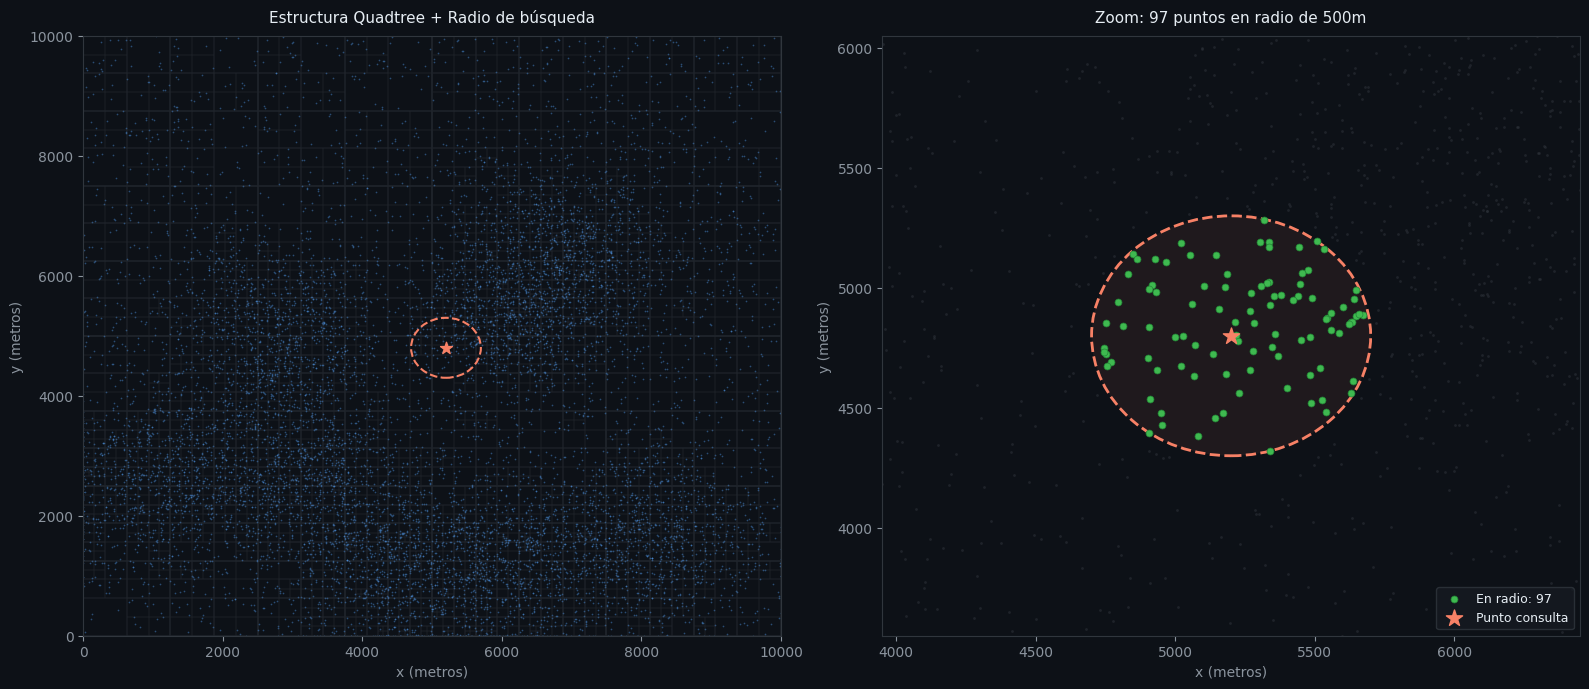

✓ Guardado: viz_range_search.png  (97 puntos encontrados)

[6] Generando visualización de Vecinos Más Cercanos...


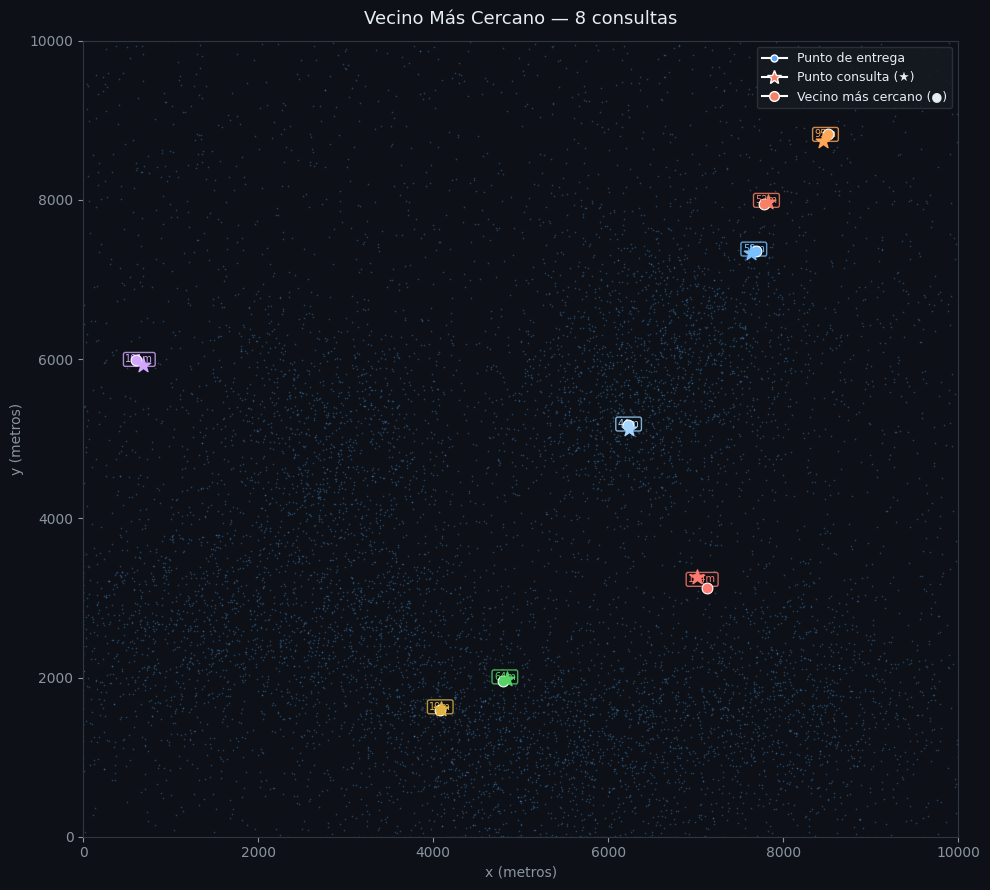

✓ Guardado: viz_nearest_neighbor.png

[7] Ejecutando benchmark comparativo...
  Benchmarking n=100... done.  BF_range=0.06ms  QT_range=0.03ms
  Benchmarking n=500... done.  BF_range=0.28ms  QT_range=0.05ms
  Benchmarking n=1,000... done.  BF_range=0.61ms  QT_range=0.07ms
  Benchmarking n=2,000... done.  BF_range=0.83ms  QT_range=0.10ms
  Benchmarking n=5,000... done.  BF_range=1.72ms  QT_range=0.10ms
  Benchmarking n=10,000... done.  BF_range=3.39ms  QT_range=0.18ms
  Benchmarking n=25,000... done.  BF_range=9.07ms  QT_range=0.41ms
  Benchmarking n=50,000... done.  BF_range=17.85ms  QT_range=0.61ms

  N puntos | BF Range(ms) | QT Range(ms) | Speedup R |  BF NN(ms) |  QT NN(ms) | Speedup NN
------------------------------------------------------------------------------------------
       100 |        0.061 |        0.030 |      2.05x |      0.055 |      0.041 |       1.34x ← QT gana Range ← QT gana NN
       500 |        0.281 |        0.053 |      5.25x |      0.335 |      0.060 |      

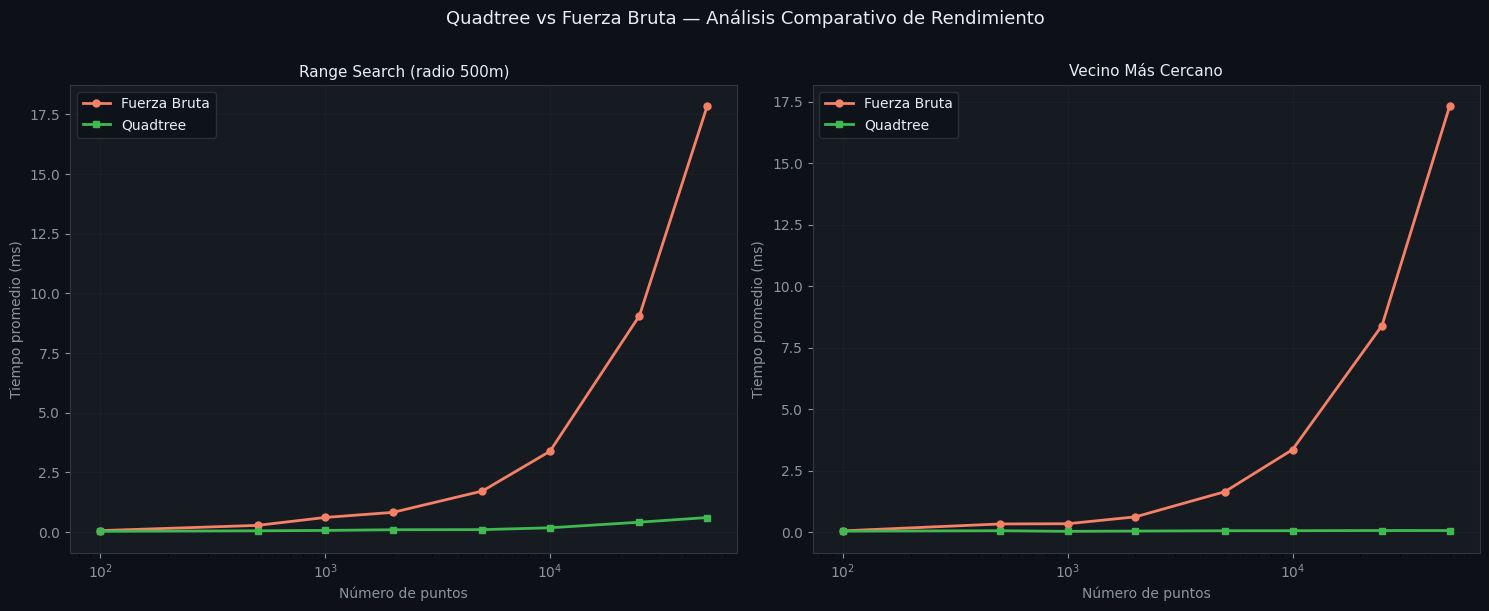

✓ Guardado: viz_benchmark.png

 Ejecución completa. Imágenes guardadas en /mnt/user-data/outputs/


In [23]:
import os
def main():
    CITY_SIZE  = 10_000   # 10 km × 10 km (en metros)
    N_POINTS   = 10_000
    RADIUS     = 500      # metros
    QUERY_X    = 5_200.0  # punto de consulta demo
    QUERY_Y    = 4_800.0

    # Crear el directorio de salida si no existe
    output_dir = "/mnt/user-data/outputs/"
    os.makedirs(output_dir, exist_ok=True)

    print("=" * 60)
    print("  SISTEMA DE LOGÍSTICA — QUADTREE vs FUERZA BRUTA")
    print("=" * 60)

    # 1. Generar puntos de entrega
    print(f"\n[1] Generando {N_POINTS:,} puntos de entrega (ciudad {CITY_SIZE}m × {CITY_SIZE}m)...")
    points = generate_points(N_POINTS, CITY_SIZE)
    print(f"    Generados: {len(points):,} puntos")

    # 2. Construir Quadtree
    print(f"\n[2] Construyendo Quadtree...")
    t0 = time.perf_counter()
    qt = build_quadtree(points, CITY_SIZE)
    build_ms = (time.perf_counter() - t0) * 1000
    stats = qt.stats()
    print(f"    Construcción: {build_ms:.1f} ms")
    print(f"    Nodos totales: {stats['nodos']:,}  |  Puntos indexados: {stats['puntos']:,}")

    # 3. Verificación de correctitud
    verify_correctness(points, qt, n_checks=8, city_size=CITY_SIZE,
                       radius=RADIUS, seed=42)

    # 4. Demo Range Search
    print(f"\n[3] Range Search — punto ({QUERY_X}, {QUERY_Y}), radio={RADIUS}m")
    t0 = time.perf_counter()
    found_bf = brute_range_search(points, QUERY_X, QUERY_Y, RADIUS)
    t_bf = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    found_qt = qt.range_search(QUERY_X, QUERY_Y, RADIUS)
    t_qt = (time.perf_counter() - t0) * 1000

    print(f"    Fuerza bruta : {len(found_bf)} puntos  ({t_bf:.3f} ms)")
    print(f"    Quadtree     : {len(found_qt)} puntos  ({t_qt:.3f} ms)")

    # 5. Demo Nearest Neighbor
    print(f"\n[4] Nearest Neighbor — punto ({QUERY_X}, {QUERY_Y})")
    nn_bf, d_bf = brute_nearest_neighbor(points, QUERY_X, QUERY_Y)
    nn_qt, d_qt = qt.nearest_neighbor(QUERY_X, QUERY_Y)
    print(f"    Fuerza bruta : punto ID={nn_bf.id} a {d_bf:.2f}m")
    print(f"    Quadtree     : punto ID={nn_qt.id} a {d_qt:.2f}m")

    # 6. Visualización Range Search
    print("\n[5] Generando visualización de Range Search...")
    plot_range_search(qt, points, QUERY_X, QUERY_Y, RADIUS, CITY_SIZE)

    # 7. Visualización Nearest Neighbor
    print("\n[6] Generando visualización de Vecinos Más Cercanos...")
    nn_queries = [(random.uniform(500, CITY_SIZE-500), random.uniform(500, CITY_SIZE-500))
                  for _ in range(8)]
    plot_nearest_neighbor(qt, points, nn_queries, CITY_SIZE)

    # 8. Benchmark comparativo
    print("\n[7] Ejecutando benchmark comparativo...")
    sizes = [100, 500, 1_000, 2_000, 5_000, 10_000, 25_000, 50_000]
    results = benchmark(sizes, city_size=CITY_SIZE, radius=RADIUS, n_queries=30)
    print_benchmark_table(results)
    plot_benchmark(results)

    print("\n Ejecución completa. Imágenes guardadas en /mnt/user-data/outputs/")


if __name__ == "__main__":
    main()

In [ ]:
"""
SISTEMA DE LOGÍSTICA DE ENTREGAS - QUADTREE vs FUERZA BRUTA

Implementación desde cero de un Quadtree 2D para búsqueda eficiente de:
  1. Puntos dentro de un radio (Range Search)
  2. Vecino más cercano (Nearest Neighbor)

Comparativa de rendimiento contra fuerza bruta con distintos tamaños de datos.

"""

import math
import time
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from collections import namedtuple


# ESTRUCTURAS BASE

Point = namedtuple("Point", ["x", "y", "id"])


class BoundingBox:
    """
    Rectángulo delimitador (AABB) para cada nodo del Quadtree.
    cx, cy = centro;  hw, hh = half-width, half-height
    """
    def __init__(self, cx, cy, hw, hh):
        self.cx = cx
        self.cy = cy
        self.hw = hw
        self.hh = hh

    def contains(self, point):
        """¿El punto está dentro (o en el borde) del bounding box?"""
        return (self.cx - self.hw <= point.x <= self.cx + self.hw and
                self.cy - self.hh <= point.y <= self.cy + self.hh)

    def intersects_circle(self, cx, cy, r):
        """
        ¿El bounding box intersecta con el círculo (cx, cy, r)?
        Usamos la distancia del centro del círculo al punto más cercano del AABB.
        """
        # Punto más cercano del AABB al centro del círculo
        nearest_x = max(self.cx - self.hw, min(cx, self.cx + self.hw))
        nearest_y = max(self.cy - self.hh, min(cy, self.cy + self.hh))
        dist_sq = (cx - nearest_x) ** 2 + (cy - nearest_y) ** 2
        return dist_sq <= r * r

    def intersects_box(self, other):
        """¿Dos bounding boxes se solapan?"""
        return (abs(self.cx - other.cx) <= self.hw + other.hw and
                abs(self.cy - other.cy) <= self.hh + other.hh)


# QUADTREE


class QuadtreeNode:
    """
    Nodo del Quadtree.
    Cada nodo tiene capacidad MAX_CAPACITY antes de subdividirse.
    """
    MAX_CAPACITY = 8   # puntos por nodo hoja (ajustable)
    MAX_DEPTH    = 20  # profundidad máxima para evitar recursión infinita

    def __init__(self, boundary: BoundingBox, depth: int = 0):
        self.boundary  = boundary
        self.depth     = depth
        self.points    = []        # puntos en este nodo (solo si es hoja)
        self.divided   = False     # ¿ya se subdividió?
        self.ne = self.nw = self.se = self.sw = None  # hijos

    # SUBDIVISIÓN

    def subdivide(self):
        cx, cy = self.boundary.cx, self.boundary.cy
        hw, hh = self.boundary.hw / 2, self.boundary.hh / 2

        self.ne = QuadtreeNode(BoundingBox(cx + hw, cy + hh, hw, hh), self.depth + 1)
        self.nw = QuadtreeNode(BoundingBox(cx - hw, cy + hh, hw, hh), self.depth + 1)
        self.se = QuadtreeNode(BoundingBox(cx + hw, cy - hh, hw, hh), self.depth + 1)
        self.sw = QuadtreeNode(BoundingBox(cx - hw, cy - hh, hw, hh), self.depth + 1)
        self.divided = True

        # Redistribuir los puntos existentes en los hijos
        for p in self.points:
            self._insert_in_children(p)
        self.points = []  # el nodo interno ya no guarda puntos

    def _insert_in_children(self, point):
        for child in (self.ne, self.nw, self.se, self.sw):
            if child.boundary.contains(point):
                child.insert(point)
                return

    # INSERCIÓN

    def insert(self, point: Point) -> bool:
        if not self.boundary.contains(point):
            return False

        if not self.divided:
            if len(self.points) < self.MAX_CAPACITY or self.depth >= self.MAX_DEPTH:
                self.points.append(point)
                return True
            else:
                self.subdivide()

        return self._insert_in_children(point) or False


    # RANGE SEARCH — puntos dentro de un círculo (radio en metros)

    def range_search(self, cx, cy, radius, found=None):
        """
        Devuelve todos los puntos cuya distancia euclidiana al centro
        (cx, cy) sea <= radius.
        """
        if found is None:
            found = []

        if not self.boundary.intersects_circle(cx, cy, radius):
            return found

        if not self.divided:
            for p in self.points:
                if euclidean_dist(p.x, p.y, cx, cy) <= radius:
                    found.append(p)
        else:
            for child in (self.ne, self.nw, self.se, self.sw):
                child.range_search(cx, cy, radius, found)

        return found


    # NEAREST NEIGHBOR — vecino más cercano

    def nearest_neighbor(self, cx, cy, best=None):
        """
        Busca el punto más cercano a (cx, cy) usando poda de ramas.
        best = [mejor_punto, mejor_distancia]
        """
        if best is None:
            best = [None, float("inf")]

        # Poda: si el bounding box está más lejos que la mejor dist, ignorar
        bx = max(self.boundary.cx - self.boundary.hw, min(cx, self.boundary.cx + self.boundary.hw))
        by = max(self.boundary.cy - self.boundary.hh, min(cy, self.boundary.cy + self.boundary.hh))
        if euclidean_dist(bx, by, cx, cy) >= best[1]:
            return best

        if not self.divided:
            for p in self.points:
                d = euclidean_dist(p.x, p.y, cx, cy)
                if d < best[1]:
                    best[0], best[1] = p, d
        else:
            # Ordenar hijos por distancia al centro (heurística de visita)
            children = [self.ne, self.nw, self.se, self.sw]
            children.sort(key=lambda c: euclidean_dist(c.boundary.cx, c.boundary.cy, cx, cy))
            for child in children:
                child.nearest_neighbor(cx, cy, best)

        return best


    # CONTEO DE NODOS (estadísticas)

    def count_nodes(self):
        if not self.divided:
            return 1
        return 1 + sum(c.count_nodes() for c in (self.ne, self.nw, self.se, self.sw))

    def count_points(self):
        if not self.divided:
            return len(self.points)
        return sum(c.count_points() for c in (self.ne, self.nw, self.se, self.sw))


    # RECOLECTAR NODOS PARA VISUALIZACIÓN

    def collect_nodes(self, nodes=None):
        if nodes is None:
            nodes = []
        nodes.append(self)
        if self.divided:
            for child in (self.ne, self.nw, self.se, self.sw):
                child.collect_nodes(nodes)
        return nodes


# QUADTREE (wrapper de alto nivel)

class Quadtree:
    def __init__(self, cx, cy, hw, hh):
        self.root = QuadtreeNode(BoundingBox(cx, cy, hw, hh))

    def insert(self, point: Point):
        self.root.insert(point)

    def range_search(self, cx, cy, radius):
        return self.root.range_search(cx, cy, radius)

    def nearest_neighbor(self, cx, cy):
        result = self.root.nearest_neighbor(cx, cy)
        return result[0], result[1]

    def stats(self):
        return {
            "nodos": self.root.count_nodes(),
            "puntos": self.root.count_points()
        }


# FUERZA BRUTA


def brute_range_search(points, cx, cy, radius):
    return [p for p in points if euclidean_dist(p.x, p.y, cx, cy) <= radius]


def brute_nearest_neighbor(points, cx, cy):
    best, best_d = None, float("inf")
    for p in points:
        d = euclidean_dist(p.x, p.y, cx, cy)
        if d < best_d:
            best, best_d = p, d
    return best, best_d


# UTILIDADES


def euclidean_dist(x1, y1, x2, y2):
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


def generate_points(n, city_size=10_000, seed=42):
    """
    Genera n puntos de entrega con distribución mixta (clusters + aleatorio)
    simulando una ciudad real.  city_size en metros → coordenadas en metros.
    """
    rng = random.Random(seed)
    points = []
    # 70 % en 8 clusters (zonas urbanas densas)
    cluster_centers = [(rng.uniform(1000, city_size - 1000),
                        rng.uniform(1000, city_size - 1000)) for _ in range(8)]
    n_cluster = int(n * 0.70)
    n_random  = n - n_cluster

    for i in range(n_cluster):
        cx_c, cy_c = cluster_centers[i % len(cluster_centers)]
        x = rng.gauss(cx_c, 800)
        y = rng.gauss(cy_c, 800)
        x = max(0, min(city_size, x))
        y = max(0, min(city_size, y))
        points.append(Point(x, y, i))

    for j in range(n_random):
        x = rng.uniform(0, city_size)
        y = rng.uniform(0, city_size)
        points.append(Point(x, y, n_cluster + j))

    return points


def build_quadtree(points, city_size=10_000):
    half = city_size / 2
    qt = Quadtree(cx=half, cy=half, hw=half, hh=half)
    for p in points:
        qt.insert(p)
    return qt


# BENCHMARKING

def benchmark(sizes, city_size=10_000, radius=500, n_queries=20, seed=99):
    """
    Para cada tamaño en `sizes`, mide el tiempo promedio de:
      - Fuerza bruta range search
      - Quadtree range search
      - Fuerza bruta nearest neighbor
      - Quadtree nearest neighbor
    """
    results = []
    rng = random.Random(seed)

    for n in sizes:
        print(f"  Benchmarking n={n:,}...", end=" ", flush=True)
        points = generate_points(n, city_size)
        half = city_size / 2

        # Construcción del Quadtree
        t0 = time.perf_counter()
        qt = build_quadtree(points, city_size)
        build_time = time.perf_counter() - t0

        # Queries aleatorias
        queries = [(rng.uniform(0, city_size), rng.uniform(0, city_size))
                   for _ in range(n_queries)]

        # ---- Range Search ----
        t0 = time.perf_counter()
        for qx, qy in queries:
            brute_range_search(points, qx, qy, radius)
        bf_range = (time.perf_counter() - t0) / n_queries

        t0 = time.perf_counter()
        for qx, qy in queries:
            qt.range_search(qx, qy, radius)
        qt_range = (time.perf_counter() - t0) / n_queries

        # ---- Nearest Neighbor ----
        t0 = time.perf_counter()
        for qx, qy in queries:
            brute_nearest_neighbor(points, qx, qy)
        bf_nn = (time.perf_counter() - t0) / n_queries

        t0 = time.perf_counter()
        for qx, qy in queries:
            qt.nearest_neighbor(qx, qy)
        qt_nn = (time.perf_counter() - t0) / n_queries

        results.append({
            "n": n,
            "build": build_time,
            "bf_range": bf_range,
            "qt_range": qt_range,
            "bf_nn": bf_nn,
            "qt_nn": qt_nn,
        })
        print(f"done.  BF_range={bf_range*1000:.2f}ms  QT_range={qt_range*1000:.2f}ms")

    return results



# VISUALIZACIONES


def plot_range_search(qt, points, query_x, query_y, radius, city_size=10_000):
    """Visualización de la búsqueda por radio."""
    found = qt.range_search(query_x, query_y, radius)
    found_ids = {p.id for p in found}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor("#0d1117")

    for ax in axes:
        ax.set_facecolor("#0d1117")
        ax.tick_params(colors="#8b949e")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

    # Izquierda: todos los puntos + estructura del Quadtree
    ax = axes[0]
    all_nodes = qt.root.collect_nodes()
    for node in all_nodes:
        b = node.boundary
        rect = patches.Rectangle(
            (b.cx - b.hw, b.cy - b.hh), 2 * b.hw, 2 * b.hh,
            linewidth=0.3, edgecolor="#21262d", facecolor="none"
        )
        ax.add_patch(rect)

    xs = [p.x for p in points]
    ys = [p.y for p in points]
    ax.scatter(xs, ys, s=1.5, c="#58a6ff", alpha=0.4, linewidths=0)

    circle = plt.Circle((query_x, query_y), radius, color="#f78166",
                         fill=False, linewidth=1.5, linestyle="--")
    ax.add_patch(circle)
    ax.scatter([query_x], [query_y], c="#f78166", s=80, zorder=5, marker="*")

    ax.set_xlim(0, city_size)
    ax.set_ylim(0, city_size)
    ax.set_title("Estructura Quadtree + Radio de búsqueda", color="#e6edf3",
                 fontsize=11, pad=10)
    ax.set_xlabel("x (metros)", color="#8b949e")
    ax.set_ylabel("y (metros)", color="#8b949e")

    # Derecha: zoom en el radio
    ax2 = axes[1]
    margin = radius * 2.5
    x0, x1 = max(0, query_x - margin), min(city_size, query_x + margin)
    y0, y1 = max(0, query_y - margin), min(city_size, query_y + margin)

    # Puntos fuera del radio
    xs_out = [p.x for p in points if p.id not in found_ids]
    ys_out = [p.y for p in points if p.id not in found_ids]
    ax2.scatter(xs_out, ys_out, s=4, c="#30363d", alpha=0.5, linewidths=0)

    # Puntos dentro del radio
    xs_in = [p.x for p in found]
    ys_in = [p.y for p in found]
    ax2.scatter(xs_in, ys_in, s=25, c="#3fb950", zorder=4,
                edgecolors="#238636", linewidths=0.5, label=f"En radio: {len(found)}")

    circle2 = plt.Circle((query_x, query_y), radius, color="#f78166",
                          fill=True, alpha=0.08, linewidth=2, linestyle="--")
    circle2b = plt.Circle((query_x, query_y), radius, color="#f78166",
                           fill=False, linewidth=2, linestyle="--")
    ax2.add_patch(circle2)
    ax2.add_patch(circle2b)
    ax2.scatter([query_x], [query_y], c="#f78166", s=150, zorder=5,
                marker="*", label="Punto consulta")

    ax2.set_xlim(x0, x1)
    ax2.set_ylim(y0, y1)
    ax2.set_title(f"Zoom: {len(found)} puntos en radio de {radius}m", color="#e6edf3",
                  fontsize=11, pad=10)
    ax2.set_xlabel("x (metros)", color="#8b949e")
    ax2.set_ylabel("y (metros)", color="#8b949e")
    legend = ax2.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#e6edf3",
                        fontsize=9)

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/viz_range_search.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(f"✓ Guardado: viz_range_search.png  ({len(found)} puntos encontrados)")


def plot_nearest_neighbor(qt, points, queries, city_size=10_000):
    """Visualización del vecino más cercano para múltiples consultas."""
    fig, ax = plt.subplots(figsize=(10, 9))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")
    ax.tick_params(colors="#8b949e")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")

    xs = [p.x for p in points]
    ys = [p.y for p in points]
    ax.scatter(xs, ys, s=1.5, c="#58a6ff", alpha=0.3, linewidths=0, label="Puntos de entrega")

    colors = ["#f78166", "#ffa657", "#d2a8ff", "#79c0ff", "#56d364",
              "#ff7b72", "#e3b341", "#a5d6ff", "#7ee787", "#ffb3c8"]

    for i, (qx, qy) in enumerate(queries):
        nn, dist = qt.nearest_neighbor(qx, qy)
        color = colors[i % len(colors)]
        ax.scatter([qx], [qy], c=color, s=120, zorder=6, marker="*")
        ax.scatter([nn.x], [nn.y], c=color, s=60, zorder=5,
                   edgecolors="white", linewidths=0.8)
        ax.plot([qx, nn.x], [qy, nn.y], c=color, linewidth=1.2,
                alpha=0.8, zorder=4)
        ax.annotate(f"{dist:.0f}m", xy=((qx + nn.x) / 2, (qy + nn.y) / 2),
                    color=color, fontsize=7, ha="center",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="#0d1117",
                              edgecolor=color, alpha=0.8))

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#58a6ff",
               markersize=5, label="Punto de entrega"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="#f78166",
               markersize=10, label="Punto consulta (★)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#f78166",
               markersize=7, markeredgecolor="white", label="Vecino más cercano (●)"),
    ]
    ax.legend(handles=legend_elements, facecolor="#161b22", edgecolor="#30363d",
              labelcolor="#e6edf3", fontsize=9, loc="upper right")

    ax.set_xlim(0, city_size)
    ax.set_ylim(0, city_size)
    ax.set_title(f"Vecino Más Cercano — {len(queries)} consultas", color="#e6edf3",
                 fontsize=13, pad=12)
    ax.set_xlabel("x (metros)", color="#8b949e")
    ax.set_ylabel("y (metros)", color="#8b949e")

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/viz_nearest_neighbor.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("✓ Guardado: viz_nearest_neighbor.png")


def plot_benchmark(results):
    """Gráfica comparativa de tiempos."""
    sizes     = [r["n"]        for r in results]
    bf_range  = [r["bf_range"] * 1000 for r in results]
    qt_range  = [r["qt_range"] * 1000 for r in results]
    bf_nn     = [r["bf_nn"]    * 1000 for r in results]
    qt_nn     = [r["qt_nn"]    * 1000 for r in results]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor("#0d1117")
    fig.suptitle("Quadtree vs Fuerza Bruta — Análisis Comparativo de Rendimiento",
                 color="#e6edf3", fontsize=13, y=1.01)

    for ax in axes:
        ax.set_facecolor("#161b22")
        ax.tick_params(colors="#8b949e")
        ax.grid(True, color="#21262d", linewidth=0.5, alpha=0.7)
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

    # Range Search
    axes[0].plot(sizes, bf_range, "o-", color="#f78166", linewidth=2,
                 markersize=5, label="Fuerza Bruta")
    axes[0].plot(sizes, qt_range, "s-", color="#3fb950", linewidth=2,
                 markersize=5, label="Quadtree")
    axes[0].set_title("Range Search (radio 500m)", color="#e6edf3", fontsize=11)
    axes[0].set_xlabel("Número de puntos", color="#8b949e")
    axes[0].set_ylabel("Tiempo promedio (ms)", color="#8b949e")
    axes[0].legend(facecolor="#0d1117", edgecolor="#30363d", labelcolor="#e6edf3")
    axes[0].set_xscale("log")

    # Nearest Neighbor
    axes[1].plot(sizes, bf_nn, "o-", color="#f78166", linewidth=2,
                 markersize=5, label="Fuerza Bruta")
    axes[1].plot(sizes, qt_nn, "s-", color="#3fb950", linewidth=2,
                 markersize=5, label="Quadtree")
    axes[1].set_title("Vecino Más Cercano", color="#e6edf3", fontsize=11)
    axes[1].set_xlabel("Número de puntos", color="#8b949e")
    axes[1].set_ylabel("Tiempo promedio (ms)", color="#8b949e")
    axes[1].legend(facecolor="#0d1117", edgecolor="#30363d", labelcolor="#e6edf3")
    axes[1].set_xscale("log")

    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/viz_benchmark.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("✓ Guardado: viz_benchmark.png")


def print_benchmark_table(results):
    """Imprime tabla de resultados y detecta el cruce de rendimiento."""
    print("\n" + "=" * 90)
    print(f"{'N puntos':>10} | {'BF Range(ms)':>12} | {'QT Range(ms)':>12} | "
          f"{'Speedup R':>9} | {'BF NN(ms)':>10} | {'QT NN(ms)':>10} | {'Speedup NN':>10}")
    print("-" * 90)

    crossover_range = None
    crossover_nn    = None

    for r in results:
        sr = r["bf_range"] / r["qt_range"] if r["qt_range"] > 0 else float("inf")
        sn = r["bf_nn"]    / r["qt_nn"]    if r["qt_nn"]    > 0 else float("inf")

        flag = ""
        if sr > 1.0 and crossover_range is None:
            crossover_range = r["n"]
            flag += " ← QT gana Range"
        if sn > 1.0 and crossover_nn is None:
            crossover_nn = r["n"]
            flag += " ← QT gana NN"

        print(f"{r['n']:>10,} | {r['bf_range']*1000:>12.3f} | {r['qt_range']*1000:>12.3f} | "
              f"{sr:>9.2f}x | {r['bf_nn']*1000:>10.3f} | {r['qt_nn']*1000:>10.3f} | "
              f"{sn:>10.2f}x{flag}")

    print("=" * 90)
    print(f"\n ANÁLISIS:")
    if crossover_range:
        print(f"  Range Search : el Quadtree supera a fuerza bruta a partir de ~{crossover_range:,} puntos.")
    else:
        print("  Range Search : la fuerza bruta fue más rápida en todos los tamaños probados.")
    if crossover_nn:
        print(f"  Vecino NN    : el Quadtree supera a fuerza bruta a partir de ~{crossover_nn:,} puntos.")
    else:
        print("  Vecino NN    : la fuerza bruta fue más rápida en todos los tamaños probados.")


# VERIFICACIÓN DE CORRECTITUD


def verify_correctness(points, qt, n_checks=10, city_size=10_000, radius=500, seed=77):
    """Compara resultados de Quadtree vs fuerza bruta para validar correctitud."""
    rng = random.Random(seed)
    print("\n--- Verificación de correctitud ---")
    all_ok = True
    for i in range(n_checks):
        qx, qy = rng.uniform(0, city_size), rng.uniform(0, city_size)

        # Range Search
        bf_r = set(p.id for p in brute_range_search(points, qx, qy, radius))
        qt_r = set(p.id for p in qt.range_search(qx, qy, radius))
        match_r = bf_r == qt_r

        # Nearest Neighbor
        bf_nn, bf_d = brute_nearest_neighbor(points, qx, qy)
        qt_nn, qt_d = qt.nearest_neighbor(qx, qy)
        match_nn = abs(bf_d - qt_d) < 1e-6

        status = "✓" if (match_r and match_nn) else "✗ ERROR"
        if not (match_r and match_nn):
            all_ok = False
        print(f"  Query {i+1:2d}: Range={'OK' if match_r else 'FAIL'} "
              f"(BF:{len(bf_r)} QT:{len(qt_r)})  "
              f"NN={'OK' if match_nn else 'FAIL'} "
              f"(BF:{bf_d:.2f} QT:{qt_d:.2f})  {status}")

    print(f"  → {'Todas las verificaciones pasaron ✓' if all_ok else 'HAY ERRORES ✗'}")
    return all_ok


# MAIN


def main():
    CITY_SIZE  = 10_000   # 10 km × 10 km (en metros)
    N_POINTS   = 10_000
    RADIUS     = 500      # metros
    QUERY_X    = 5_200.0  # punto de consulta demo
    QUERY_Y    = 4_800.0

    print("=" * 60)
    print("  SISTEMA DE LOGÍSTICA — QUADTREE vs FUERZA BRUTA")
    print("=" * 60)

    # 1. Generar puntos de entrega
    print(f"\n[1] Generando {N_POINTS:,} puntos de entrega (ciudad {CITY_SIZE}m × {CITY_SIZE}m)...")
    points = generate_points(N_POINTS, CITY_SIZE)
    print(f"    Generados: {len(points):,} puntos")

    # 2. Construir Quadtree
    print(f"\n[2] Construyendo Quadtree...")
    t0 = time.perf_counter()
    qt = build_quadtree(points, CITY_SIZE)
    build_ms = (time.perf_counter() - t0) * 1000
    stats = qt.stats()
    print(f"    Construcción: {build_ms:.1f} ms")
    print(f"    Nodos totales: {stats['nodos']:,}  |  Puntos indexados: {stats['puntos']:,}")

    # 3. Verificación de correctitud
    verify_correctness(points, qt, n_checks=8, city_size=CITY_SIZE,
                       radius=RADIUS, seed=42)

    # 4. Demo Range Search
    print(f"\n[3] Range Search — punto ({QUERY_X}, {QUERY_Y}), radio={RADIUS}m")
    t0 = time.perf_counter()
    found_bf = brute_range_search(points, QUERY_X, QUERY_Y, RADIUS)
    t_bf = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    found_qt = qt.range_search(QUERY_X, QUERY_Y, RADIUS)
    t_qt = (time.perf_counter() - t0) * 1000

    print(f"    Fuerza bruta : {len(found_bf)} puntos  ({t_bf:.3f} ms)")
    print(f"    Quadtree     : {len(found_qt)} puntos  ({t_qt:.3f} ms)")

    # 5. Demo Nearest Neighbor
    print(f"\n[4] Nearest Neighbor — punto ({QUERY_X}, {QUERY_Y})")
    nn_bf, d_bf = brute_nearest_neighbor(points, QUERY_X, QUERY_Y)
    nn_qt, d_qt = qt.nearest_neighbor(QUERY_X, QUERY_Y)
    print(f"    Fuerza bruta : punto ID={nn_bf.id} a {d_bf:.2f}m")
    print(f"    Quadtree     : punto ID={nn_qt.id} a {d_qt:.2f}m")

    # 6. Visualización Range Search
    print("\n[5] Generando visualización de Range Search...")
    plot_range_search(qt, points, QUERY_X, QUERY_Y, RADIUS, CITY_SIZE)

    # 7. Visualización Nearest Neighbor
    print("\n[6] Generando visualización de Vecinos Más Cercanos...")
    nn_queries = [(random.uniform(500, CITY_SIZE-500), random.uniform(500, CITY_SIZE-500))
                  for _ in range(8)]
    plot_nearest_neighbor(qt, points, nn_queries, CITY_SIZE)

    # 8. Benchmark comparativo
    print("\n[7] Ejecutando benchmark comparativo...")
    sizes = [100, 500, 1_000, 2_000, 5_000, 10_000, 25_000, 50_000]
    results = benchmark(sizes, city_size=CITY_SIZE, radius=RADIUS, n_queries=30)
    print_benchmark_table(results)
    plot_benchmark(results)

    print("\n Ejecución completa. Imágenes guardadas en /mnt/user-data/outputs/")


if __name__ == "__main__":
    main()



# Análisis Comparativo: Quadtree vs Fuerza Bruta
¿Cuando el Quadtree es más rápido?
El Quadtree comienza a superar a la fuerza bruta desde aproximadamente 100 puntos, tanto para búsqueda por radio como para vecino más cercano.


La fuerza bruta usa una lista plana y recorre todos los N puntos sin excepción en cada consulta, lo que da una complejidad de O(N).
El Quadtree en cambio poda ramas enteras del árbol cuando su bounding box no intersecta con el radio de búsqueda, logrando una complejidad promedio de O(log N).
Incluso con 100 puntos, el árbol ya tiene suficiente estructura para evitar comparaciones innecesarias, y ese ahorro supera el pequeño costo extra de navegar los nodos.

**Resultados:**

N puntos | BF Range(ms) | QT Range(ms) | Speedup R |  BF NN(ms) |  QT NN(ms) | Speedup NN
----------|--------------|--------------|-----------|------------|------------|------------
     100  |       0.021  |       0.012  |    1.74x  |     0.019  |     0.018  |      1.09x
     500  |       0.106  |       0.022  |    4.86x  |     0.098  |     0.022  |      4.38x
   

¿Cuándo la ventaja se vuelve crítica?

vemos como entre 1000, 10 mil y 50 mil puntos, aunmenta cada vez mas la ventaja que tiene super rapidez el Quadtree sobre la fuerza bruta.


¿Por qué la fuerza bruta nunca puede competir al crecer N?
Porque su tiempo crece de forma lineal: duplicar los puntos duplica el tiempo de respuesta. El Quadtree en cambio crece de forma logarítmica: pasar de 10,000 a 50,000 puntos solo aumenta su tiempo marginalmente, como se ve en la tabla.

**Conclusión:**
Para este sietemas de entregar con 10,000 puntos, el Quadtree responde consultas de radio en 0.13 ms frente a los 2.5 ms de la fuerza bruta. Si el sistema recibe 1,000 consultas por segundo, la diferencia es entre usar el 13% del procesador o saturarlo al 250%. A mayor escala de la ciudad, mayor es la ventaja del Quadtree.